# Ucitavanje potrebnih biblioteka

In [4]:
USE_WIDGETS = True

def importEssentialLibs(USE_WIDGETS):
    import numpy as np
    if USE_WIDGETS:
        %matplotlib widget
    else:
        %matplotlib inline
    import matplotlib as mpl
    mpl.rc('text', usetex = True)
    mpl.rc('font', family = 'serif', size = 18)
    import matplotlib.pyplot as plt
    
    return np, mpl, plt

np, mpl, plt = importEssentialLibs(USE_WIDGETS)
from IPython.display import Markdown, display
# mpl.rc('text', usetex = True)
import scipy.fft as fft
import IPython
from IPython.display import Markdown
from scipy.io import wavfile
from scipy.signal import chirp, spectrogram
import scipy.signal as signal
import pickle 
import scipy.io as sio
from scipy.signal import butter, lfilter, freqz
from scipy.signal import firwin, convolve
from fxpmath import Fxp
from signal_utils import *

## Ucitavanje ulaznih signala

In [5]:
matContentsProject = sio.loadmat('./data/sonar_signals.mat')
rxChirp = matContentsProject['rxChirp'].squeeze()
txChirp = matContentsProject['txChirp'].squeeze()
mixChirp = rxChirp * txChirp
mixChirp /= np.max(np.abs(mixChirp))
# print(np.min(mixChirp), np.max(mixChirp))

## Definisanje bitnih parametara

In [6]:
N = len(rxChirp)
fs = 200e3    # 200 kHz

AdB = 40
D = 2

c = 1500
betha = (60-20)*1e3/0.01
d_factor = c/2/betha

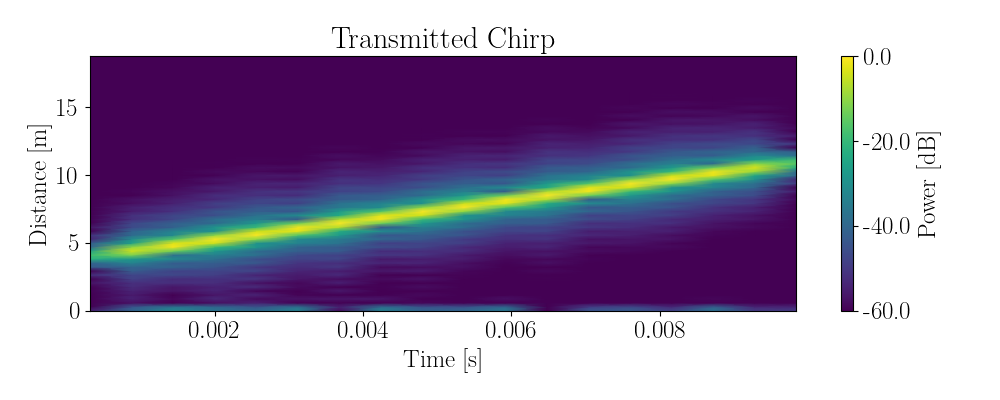

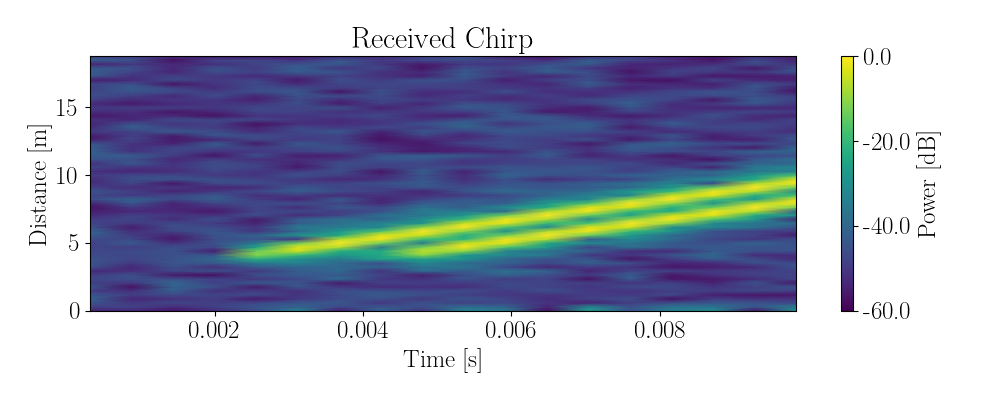

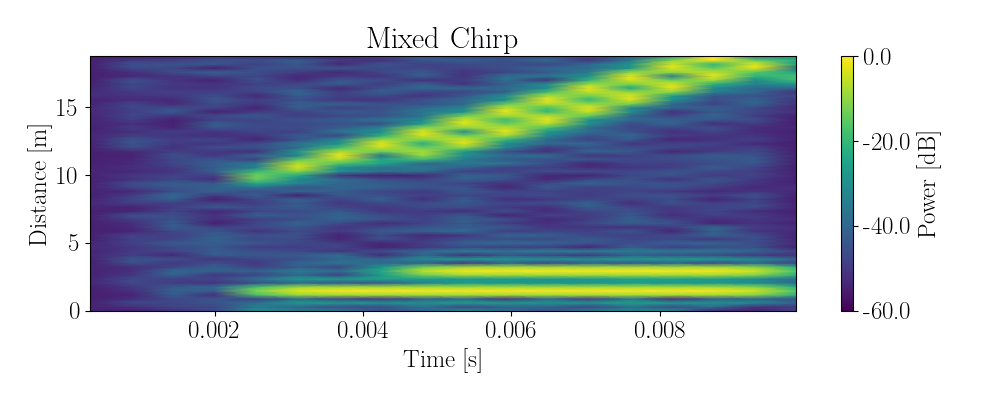

In [7]:
plot_spectrogram(txChirp/np.max(txChirp), fs, title="Transmitted Chirp", y_factor=d_factor, y_label="Distance [m]", nperseg=128, noverlap=None, db_min=-60)
plot_spectrogram(rxChirp/np.max(rxChirp), fs, title="Received Chirp", y_factor=d_factor, y_label="Distance [m]", nperseg=128, noverlap=None, db_min=-60)
plot_spectrogram(mixChirp/np.max(mixChirp), fs, title="Mixed Chirp", y_factor=d_factor, y_label="Distance [m]", nperseg=128, noverlap=None, db_min=-60)

## NF FIR filter za decimaciju

Pretpostavlja se da maksimalna frekvencija korisnog signala iznosi **15% od maksimalne (Nyquist-ove) frekvencije** \( F = 0.5 \), kako bi se omogućio dizajn filtera sa ograničenim brojem koeficijenata.

Granična frekvencija propusnog opsega određuje se u skladu sa sadržajem signala, dok se **frekvencija zaustavnog opsega** postavlja na:

\[
F_{\text{stop}} = \frac{0.5}{D}
\]

gde je \( D \) faktor decimacije.

Za projektovanje ovog niskopropusnog FIR filtra koristi se **Remezov algoritam**, koji omogućava optimalno pozicioniranje nultih tačaka u frekvencijskom domenu tako da zadovolji uslove u propusnom i nepropusnom opsegu.

Na taj način, filter efikasno potiskuje spektralne replike koje bi, usled decimacije, dovele do **aliasinga**.

$F_{max} = 0.425$

$F_{\text{pass}} = 0.1300, \quad F_{\text{stop}} = 0.2300$

$N_{FIR} = 21$

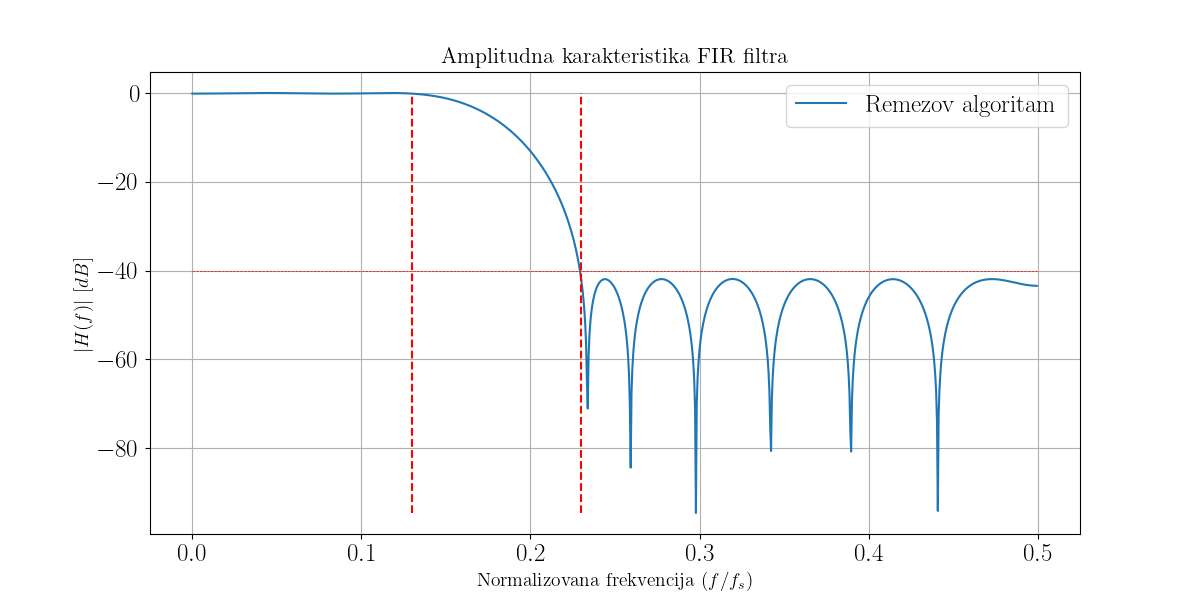

Filtar dobijen Remezovim algoritmom:
[-0.00862784 -0.0093991   0.00759768  0.02431604  0.01719255 -0.02873713
 -0.06446049 -0.02412427  0.11786376  0.28422295  0.36022782  0.28422295
  0.11786376 -0.02412427 -0.06446049 -0.02873713  0.01719255  0.02431604
  0.00759768 -0.0093991  -0.00862784]


In [8]:
deltaPass = 10**(-AdB/20)
deltaStop = deltaPass

perc = 0.15
Fmax = 0.5 * (1 - perc)
display(Markdown((rf"$F_{{max}} = {Fmax}$")))
# Fpass = Fmax / D
# Fstop = (1-Fmax) / D
Fstop = 0.23
Fpass = Fstop - 0.1

display(Markdown(rf"$F_{{\text{{pass}}}} = {Fpass:.4f}, \quad F_{{\text{{stop}}}} = {Fstop:.4f}$"))

firCoeff = remezlp(Fpass, Fstop, deltaPass, deltaStop, even_n=False, nPoints=N, Nmax=N)

# firCoeff_hb = firCoeff.copy()
# # Zero all odd indices
# firCoeff_hb[1::2] = 0
# mid = (firCoeff_hb.size-1)//2
# firCoeff_hb[mid] = 0.5


display(Markdown(rf"$N_{{FIR}} = {len(firCoeff)}$"))

w, h = scipy.signal.freqz(firCoeff, worN=len(mixChirp)//2)
H = 20*np.log10(abs(h))
H -= np.max(H)
H_full = np.concatenate((H[::-1], H))

# w_hb, h_hb = scipy.signal.freqz(firCoeff_hb)
# H_hb = 20*np.log10(abs(h_hb))
# H_hb -= np.max(H_hb)

plt.figure(figsize=(12,6))
plt.plot(w/(2*np.pi), H, label="Remezov algoritam");
# plt.plot(w_hb/(2*np.pi), H_hb, label="HB korekcija");
plt.plot([0, 0.5], [-AdB, -AdB], 'r--', linewidth=0.5)
plt.plot([Fpass,Fpass], [np.min(H), 0], 'r--');
plt.plot([Fstop,Fstop], [np.min(H), 0], 'r--');
plt.legend()
plt.title(r'Amplitudna karakteristika FIR filtra', fontsize=16)
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.grid(True)
plt.show();

np.set_printoptions(suppress=True)
print("Filtar dobijen Remezovim algoritmom:")
print(firCoeff)
# print("\nHB korekcija:")
# print(firCoeff_hb)

## Spektogram Decimiranog Mix Signala

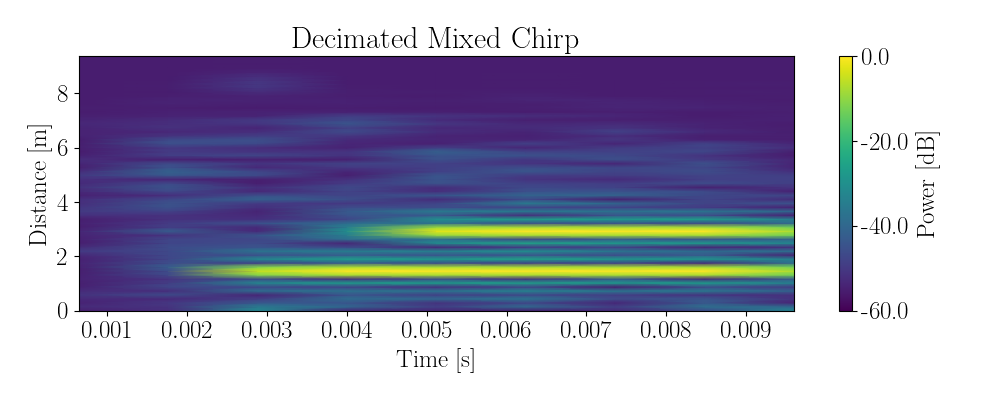

In [9]:
mixChirp_decimated = polyD(mixChirp, firCoeff, D)
plot_spectrogram(mixChirp_decimated, fs/2, title="Decimated Mixed Chirp", y_factor=d_factor, y_label="Distance [m]", nperseg=128, noverlap=None, db_min=-60)

## Amplitudska Karakteristika Originalnog i Decimiranog Signala

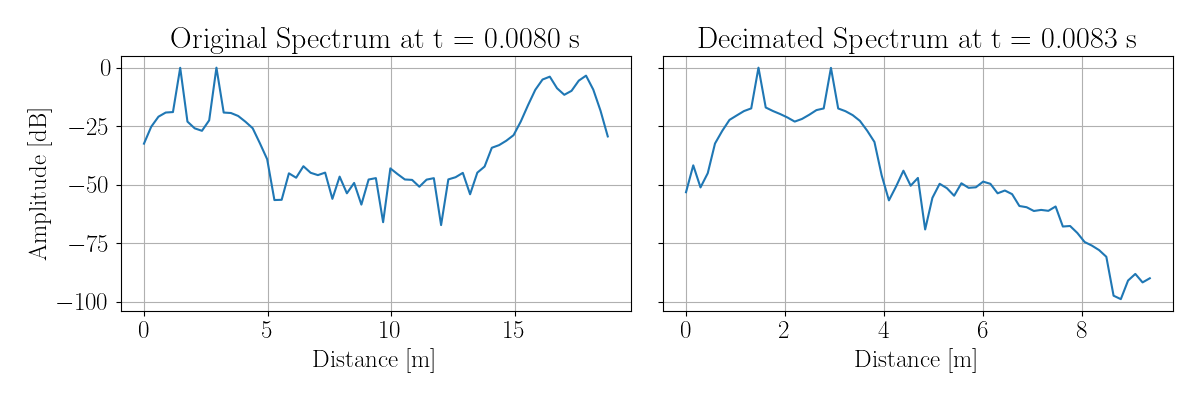

In [10]:
# Parameters
t_target = 0.008  # seconds

# Compute spectrograms
spectrograms = [
    {
        "signal": mixChirp,
        "fs": fs,
        "label": "Original",
    },
    {
        "signal": mixChirp_decimated,
        "fs": fs / 2,
        "label": "Decimated",
    }
]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i, spec in enumerate(spectrograms):
    f, t, Sxx = scipy.signal.spectrogram(
        spec["signal"],
        fs=spec["fs"],
        nperseg=128,
        noverlap=64
    )

    # Find closest time index
    idx = np.argmin(np.abs(t - t_target))

    # Get spectrum at that time
    spectrum_db = 10 * np.log10(Sxx[:, idx] + 1e-15)
    spectrum_db -= np.max(spectrum_db)

    # X-axis: converted from frequency to distance
    x_axis = f * d_factor

    axs[i].plot(x_axis, spectrum_db)
    axs[i].set_title(f"{spec['label']} Spectrum at t = {t[idx]:.4f} s")
    axs[i].set_xlabel("Distance [m]")
    axs[i].grid(True)

axs[0].set_ylabel("Amplitude [dB]")
plt.tight_layout()
plt.show()


## Udaljenost Meta [m]

In [11]:
# Find peak indices
peak_indices, _ = scipy.signal.find_peaks(spectrum_db, height=-10)
for i in range(len(peak_indices)):
    print(f"Meta {i+1}: {np.round(f[peak_indices[i]]*d_factor,3)} m")

Meta 1: 1.465 m
Meta 2: 2.93 m


# Decimacija u Fixed-Point Aritmetici

In [12]:
n_word = 8
n_frac = 7

display(Markdown(rf"$N_{{word}} = {n_word}, \quad N_{{frac}} = {n_frac}$"))

$N_{word} = 8, \quad N_{frac} = 7$

## Poredjenje mix signala u Floating-Point i Fixed-Point

Postoji DC vrednost u reprezentaciji u Fixed-Point reprezentaciji zbog toga sto signal izalzi iz opsega za predstavu u formatu Q1.n.

$X_{min} = -1.0, \quad X_{max} = 0.798$

2048


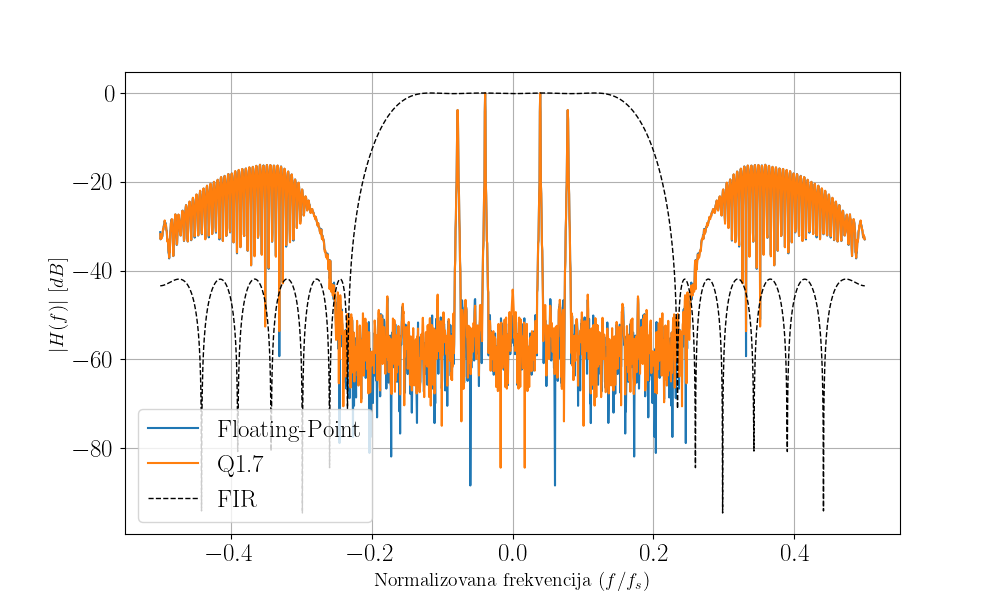

In [13]:
mixChirp_q1n = float_to_q1n(mixChirp, n_frac)
display(Markdown(rf"$X_{{min}} = {np.round(np.min(mixChirp), 3)}, \quad X_{{max}} = {np.round(np.max(mixChirp), 3)}$"))

mixChirp_fftdB = fftdB(mixChirp, win=True)
mixChirp_fftdB -= np.max(mixChirp_fftdB)
mixChirp_q1n_fftdB = fftdB(mixChirp_q1n, win=True)
mixChirp_q1n_fftdB -= np.max(mixChirp_q1n_fftdB)
freqs = np.linspace(-0.5, 0.5, len(mixChirp_fftdB))
print(len(freqs))

plt.figure(figsize=(10, 6))
plt.plot(freqs, mixChirp_fftdB, label = "Floating-Point")
plt.plot(freqs, mixChirp_q1n_fftdB, label = f"Q1.{n_frac}")
plt.plot(freqs, H_full, '--k', linewidth=1, label="FIR")
plt.grid()
plt.legend()
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.show();

## FIR Filtar u Fixed-Point Aritmetici

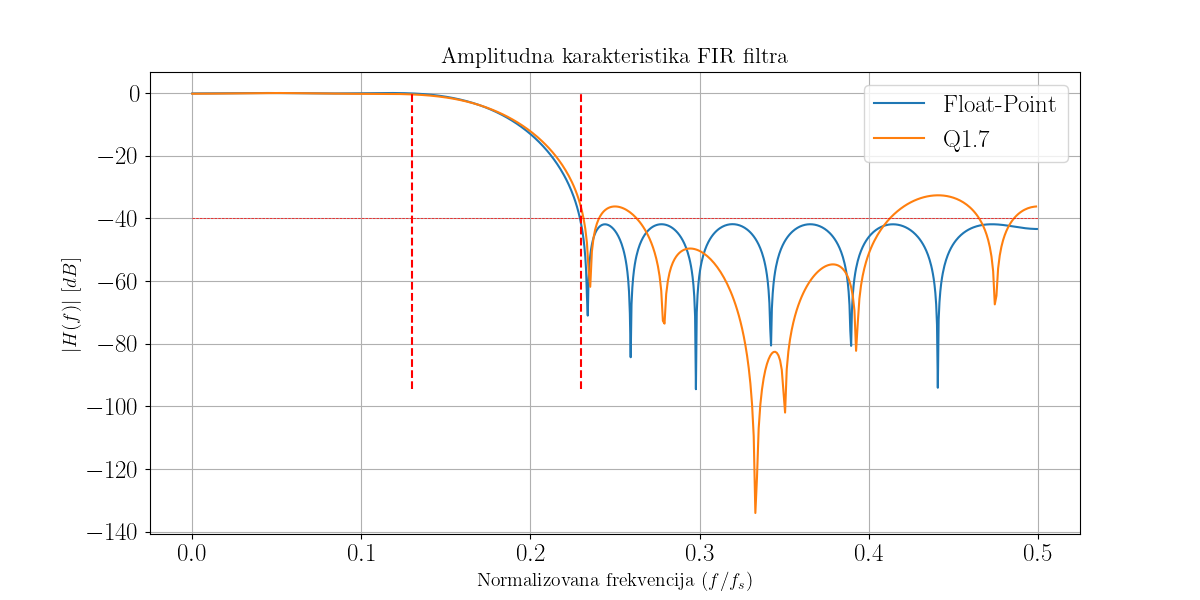

In [14]:
firCoeff_q1n = float_to_q1n(firCoeff, n_frac)

w_q1n, h_q1n = scipy.signal.freqz(firCoeff_q1n)
H_q1n = 20*np.log10(abs(h_q1n))
H_q1n -= np.max(H_q1n)

plt.figure(figsize=(12,6))
plt.plot(w/(2*np.pi), H, label=r'Float-Point');
plt.plot(w_q1n/(2*np.pi), H_q1n, label=rf'Q1.{n_frac}');
plt.plot([0, 0.5], [-AdB, -AdB], 'r--', linewidth=0.5)
plt.legend()
plt.plot([Fpass,Fpass], [np.min(H), 0], 'r--');
plt.plot([Fstop,Fstop], [np.min(H), 0], 'r--');
plt.title(r'Amplitudna karakteristika FIR filtra', fontsize=16)
plt.xlabel(r'Normalizovana frekvencija ($f/f_s$)', fontsize=14)
plt.ylabel(r'$|H(f)| \ [dB]$', fontsize=14)
plt.grid(True)
plt.show();

## Spektogram decimiranog MIX Signala u Fixed-Point Aritemetici

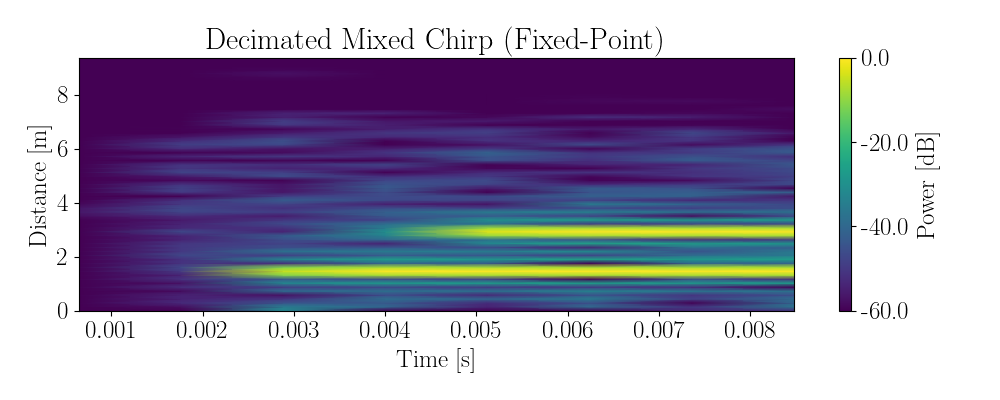

In [15]:
mixChirp_decimated_q1n = poly_decimation_q1n(mixChirp_q1n, firCoeff_q1n, D, n_frac)[:-2]

plot_spectrogram(mixChirp_decimated_q1n, fs/2, title="Decimated Mixed Chirp (Fixed-Point)", y_factor=d_factor, y_label="Distance [m]", nperseg=128, noverlap=None, db_min=-60)

## Amplitudska Karakteristika Originalnog i Decimiranog Signala

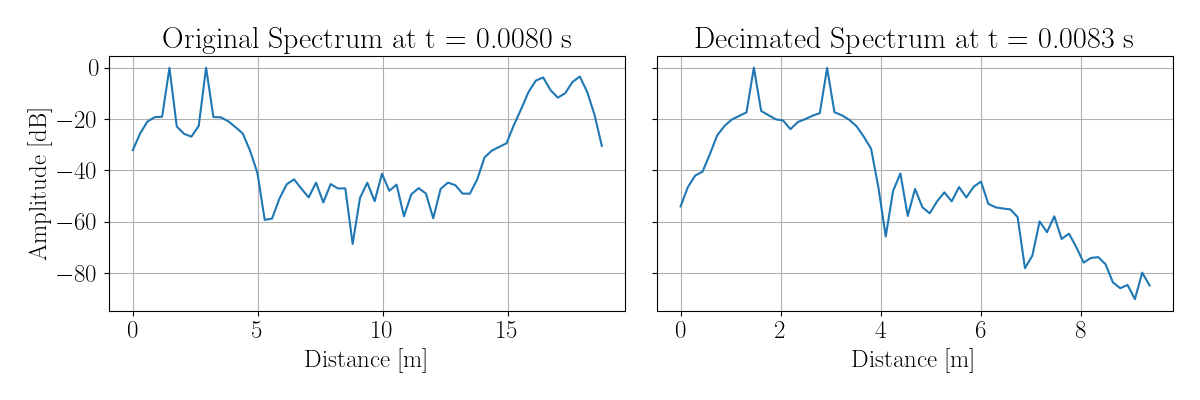

In [16]:
# Parameters
t_target = 0.008  # seconds

# Compute spectrograms
spectrograms = [
    {
        "signal": np.array(mixChirp_q1n),
        "fs": fs,
        "label": "Original",
    },
    {
        "signal": np.array(mixChirp_decimated_q1n),
        "fs": fs / 2,
        "label": "Decimated",
    }
]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for i, spec in enumerate(spectrograms):
    f, t, Sxx = scipy.signal.spectrogram(
        spec["signal"],
        fs=spec["fs"],
        nperseg=128,
        noverlap=64
    )

    # Find closest time index
    idx = np.argmin(np.abs(t - t_target))

    # Get spectrum at that time
    spectrum_q1n_db = 10 * np.log10(Sxx[:, idx] + 1e-15)
    spectrum_q1n_db -= np.max(spectrum_q1n_db)

    # X-axis: converted from frequency to distance
    x_axis = f * d_factor

    axs[i].plot(x_axis, spectrum_q1n_db)
    axs[i].set_title(f"{spec['label']} Spectrum at t = {t[idx]:.4f} s")
    axs[i].set_xlabel("Distance [m]")
    axs[i].grid(True)

axs[0].set_ylabel("Amplitude [dB]")
plt.tight_layout()
plt.show()


## Udaljenost Meta [m]

In [17]:
# Find peak indices
peak_indices, _ = scipy.signal.find_peaks(spectrum_q1n_db, height=-10)
for i in range(len(peak_indices)):
    print(f"Meta {i+1}: {np.round(f[peak_indices[i]]*d_factor,3)} m")

Meta 1: 1.465 m
Meta 2: 2.93 m


# Generisanje txt fajlova za VHDL simulaciju

In [18]:
firCoeff_poly = makePolyphase(firCoeff_q1n, D)
np.savetxt("../vhdl/poly_dec_RAG/data/fir_coeffs_phase0.txt", firCoeff_poly[0], fmt="%d")
np.savetxt("../vhdl/poly_dec_RAG/data/fir_coeffs_phase1.txt", firCoeff_poly[1], fmt="%d")
np.savetxt("../vhdl/poly_dec_RAG/data/mixChirp_q1n.txt", mixChirp_q1n, fmt="%d")

# Poredjenje rezultata VHDL i python simulacije 

Error sum: 0


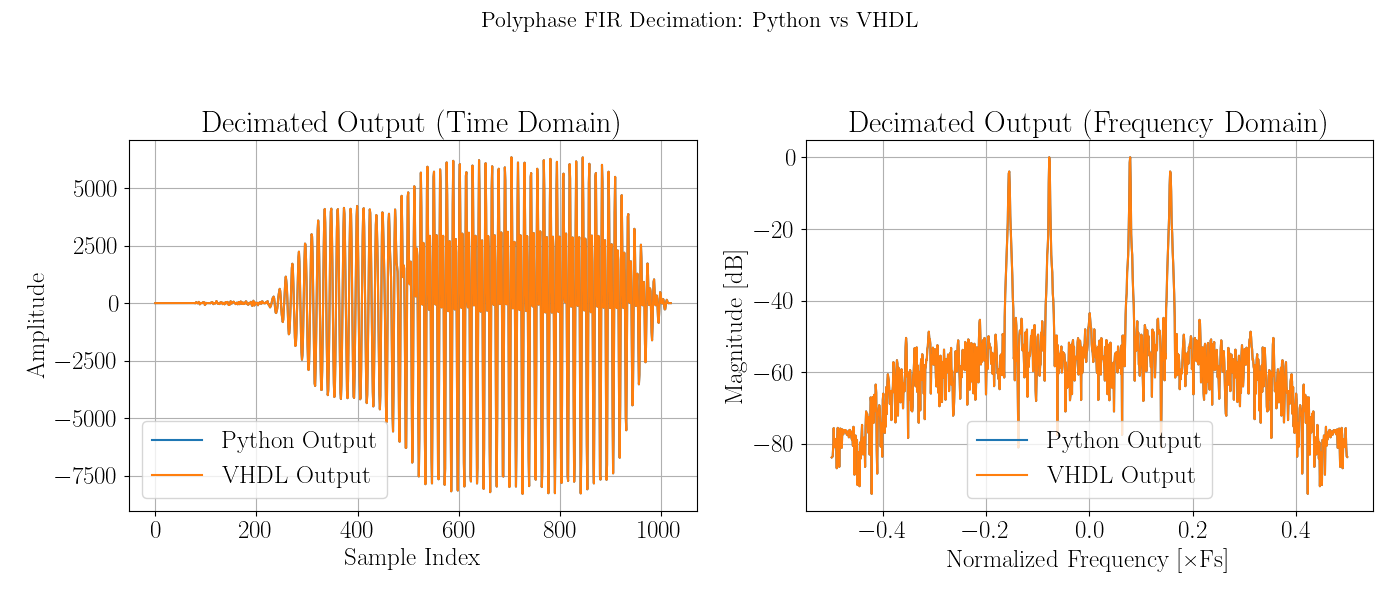

In [19]:
xout_py_dec = mixChirp_decimated_q1n[:-2]
xout_vhdl_dec = np.loadtxt("../vhdl/poly_dec_RAG/data/mixChirp_dec_q1n.txt", dtype=np.int32)[3:]

# print(len(xout_py_dec), len(xout_vhdl_dec))

xout_py_dec_fftdB = fftdB(xout_py_dec, win=True)
xout_py_dec_fftdB -= np.max(xout_py_dec_fftdB)
xout_vhdl_dec_fftdB = fftdB(xout_vhdl_dec, win=True)
xout_vhdl_dec_fftdB -= np.max(xout_vhdl_dec_fftdB)

error = np.abs(xout_py_dec-xout_vhdl_dec)
print(f"Error sum: {np.sum(error)}")

freqs = np.linspace(-0.5, 0.5, len(xout_py_dec_fftdB))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Polyphase FIR Decimation: Python vs VHDL", fontsize=16, fontweight='bold')

# Time Domain Plot
axs[0].plot(xout_py_dec, label="Python Output")
axs[0].plot(xout_vhdl_dec, label="VHDL Output")
axs[0].set_title("Decimated Output (Time Domain)")
axs[0].set_xlabel("Sample Index")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
axs[0].legend(loc="best")

# Frequency Domain Plot
axs[1].plot(freqs, xout_py_dec_fftdB, label="Python Output")
axs[1].plot(freqs, xout_vhdl_dec_fftdB, label="VHDL Output")
axs[1].set_title("Decimated Output (Frequency Domain)")
axs[1].set_xlabel("Normalized Frequency [×Fs]")
axs[1].set_ylabel("Magnitude [dB]")
axs[1].grid(True)
axs[1].legend(loc="best")

plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
plt.show()

# Generisanje txt fajlova za DSP implementaciju

In [22]:
np.savetxt("../mcu/data/firCoeff_q1n.txt", firCoeff_q1n, fmt="%d")
np.savetxt("../mcu/data/mixChirp_q1n.txt", mixChirp_q1n, fmt="%d")
print(firCoeff_q1n)

[-1, -1, 0, 3, 2, -3, -8, -3, 15, 36, 46, 36, 15, -3, -8, -3, 2, 3, 0, -1, -1]


# Poredjenje rezultata DSP i python implementacije 

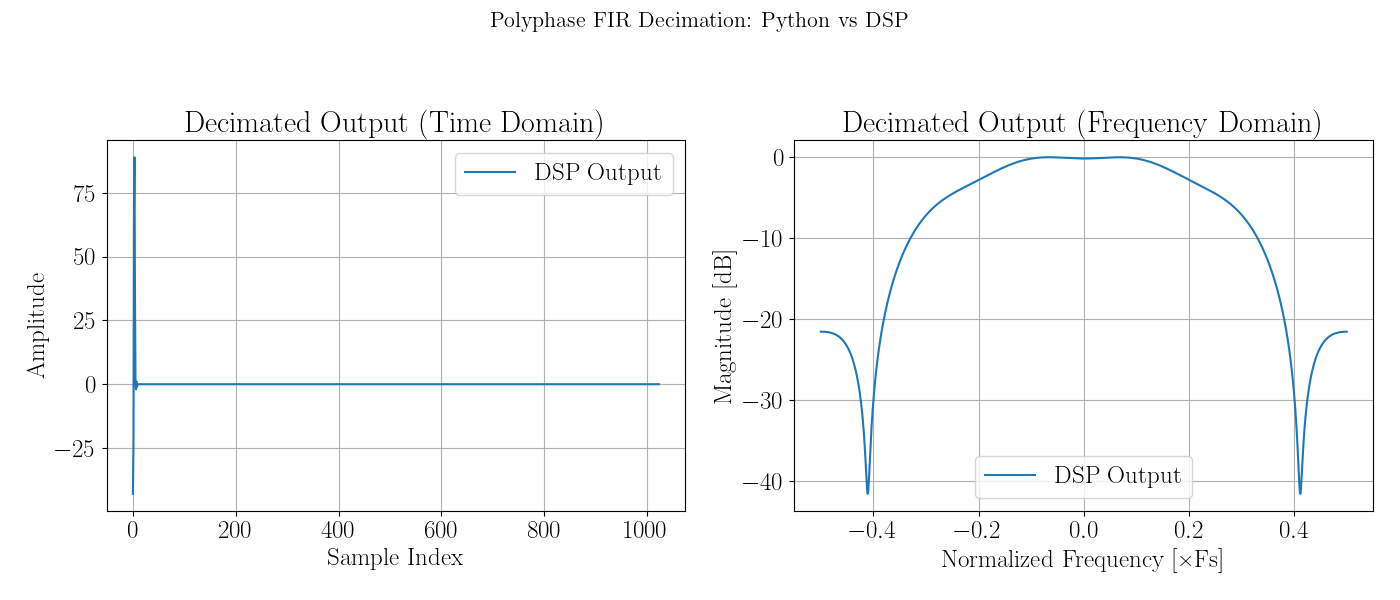

In [25]:
xout_mcu_dec = np.loadtxt("../mcu/data/xout_q1n.txt", dtype=np.int32)

xout_mcu_dec_fftdB = fftdB(xout_mcu_dec, win=True)
xout_mcu_dec_fftdB -= np.max(xout_mcu_dec_fftdB)
freqs_mcu = np.linspace(-0.5, 0.5, len(xout_mcu_dec))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Polyphase FIR Decimation: Python vs DSP", fontsize=16, fontweight='bold')

# Time Domain Plot
# axs[0].plot(xout_py_dec, label="Python Output")
axs[0].plot(xout_mcu_dec, label="DSP Output")
axs[0].set_title("Decimated Output (Time Domain)")
axs[0].set_xlabel("Sample Index")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
axs[0].legend(loc="best")

# Frequency Domain Plot
# axs[1].plot(freqs, xout_py_dec_fftdB, label="Python Output")
axs[1].plot(freqs_mcu, xout_mcu_dec_fftdB, label="DSP Output")
axs[1].set_title("Decimated Output (Frequency Domain)")
axs[1].set_xlabel("Normalized Frequency [×Fs]")
axs[1].set_ylabel("Magnitude [dB]")
axs[1].grid(True)
axs[1].legend(loc="best")

plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
plt.show()